In [17]:
# Install libraries if not already installed (uncomment in Colab)
# !pip install pandas numpy matplotlib seaborn plotly scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [18]:
# Upload your CSV (if in Colab)
try:
# Replace file upload with direct file path, e.g.: pd.read_csv('mydata.csv')
  csv_path = list(uploaded.keys())[0]
except FileNotFoundError:
  # Or manually set path to CSV file
  csv_path = "insurance.csv"  # <-- change to your CSV path
except Exception as e:
  print(f"An error occurred during file upload: {e}")
  csv_path = "insurance.csv" # Fallback to default path or handle error

try:
    df = pd.read_csv(csv_path)
    print("Dataset loaded. Shape:", df.shape)
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{csv_path}' was not found. Please upload the file or provide the correct path.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

An error occurred during file upload: name 'uploaded' is not defined
Dataset loaded. Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
# Show info
df.info()

# Show first few rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [20]:
missing_count = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)
missing_table = pd.DataFrame({"Missing Count": missing_count, "Missing %": missing_percent})
missing_table.sort_values("Missing %", ascending=False).head(50)

,Missing Count,Missing %
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


In [21]:
def detect_column_types(df):
    types = {}
    for col in df.columns:
        s = df[col]
        if pd.api.types.is_numeric_dtype(s):
            types[col] = "numeric"
        else:
            try:
                pd.to_datetime(s.dropna().sample(min(50, s.dropna().shape[0])), errors='raise')
                types[col] = "datetime"
            except Exception:
                if s.nunique(dropna=True) < 50:
                    types[col] = "categorical"
                else:
                    types[col] = "text"
    return types

col_types = detect_column_types(df)
pd.Series(col_types, name="Detected Type").head(50)

C:\Users\abhishek\AppData\Local\Temp\ipykernel_18656\1900686156.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(s.dropna().sample(min(50, s.dropna().shape[0])), errors='raise')
C:\Users\abhishek\AppData\Local\Temp\ipykernel_18656\1900686156.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(s.dropna().sample(min(50, s.dropna().shape[0])), errors='raise')
C:\Users\abhishek\AppData\Local\Temp\ipykernel_18656\1900686156.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(s.dropna().sample(min(50, s.dropna().shape[0])), errors='

age             numeric
sex         categorical
bmi             numeric
children        numeric
smoker      categorical
region      categorical
charges         numeric
Name: Detected Type, dtype: object

In [22]:
numeric_df = df.select_dtypes(include=[np.number])
if not numeric_df.empty:
    display(numeric_df.describe().T)
else:
    print("No numeric columns detected.")

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [23]:
categorical_cols = [c for c, t in col_types.items() if t == "categorical"]
for c in categorical_cols[:5]:
    print(f"\nTop values for {c}:")
    print(df[c].value_counts(dropna=False).head(10))


Top values for sex:
sex
male      676
female    662
Name: count, dtype: int64

Top values for smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

Top values for region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


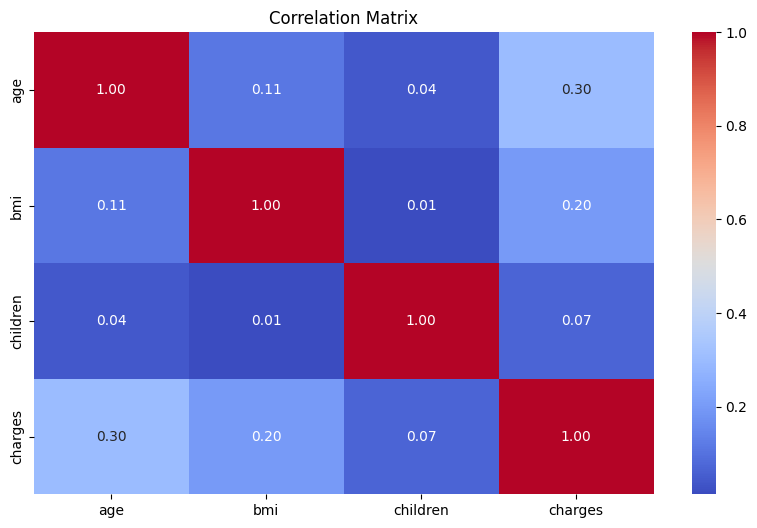

In [24]:
if numeric_df.shape[1] >= 2:
    plt.figure(figsize=(10, 6))
    sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation Matrix")
    plt.show()
else:
    print("Not enough numeric columns for correlation matrix.")

In [25]:
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_summary = {}
for col in numeric_df.columns:
    count = detect_outliers_iqr(numeric_df[col].dropna())
    outlier_summary[col] = count
pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count']).sort_values('Outlier Count', ascending=False)

,Outlier Count
charges,139
bmi,9
age,0
children,0


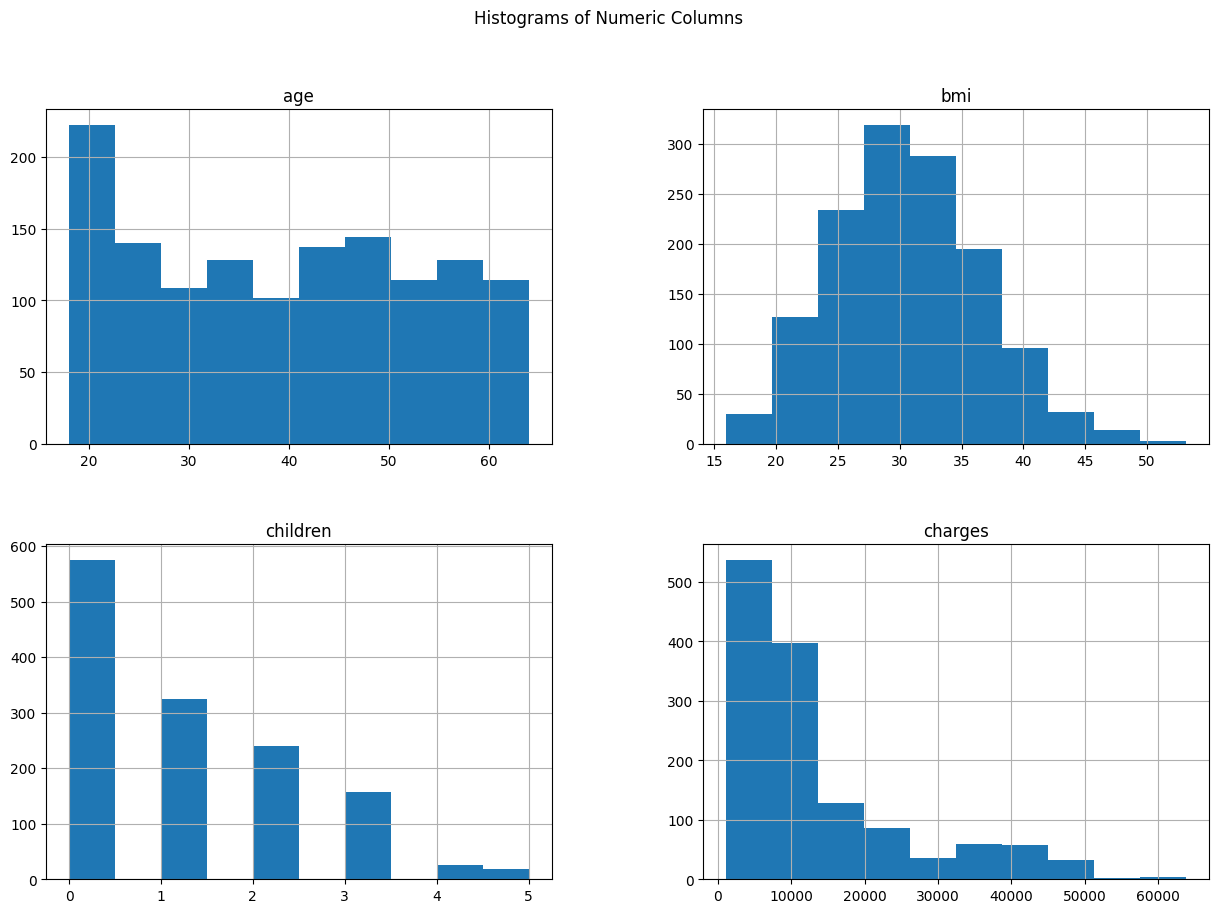

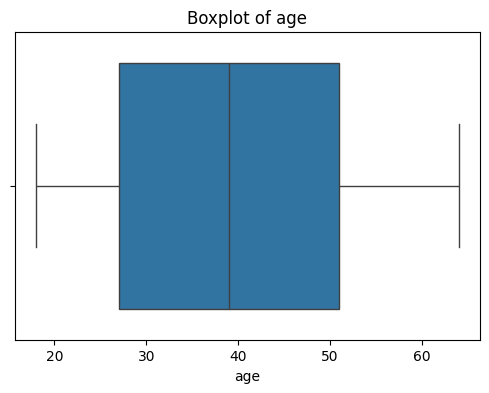

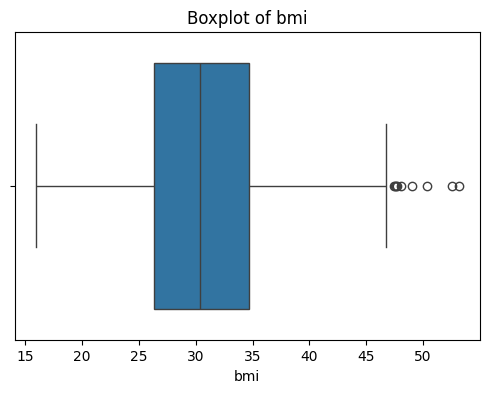

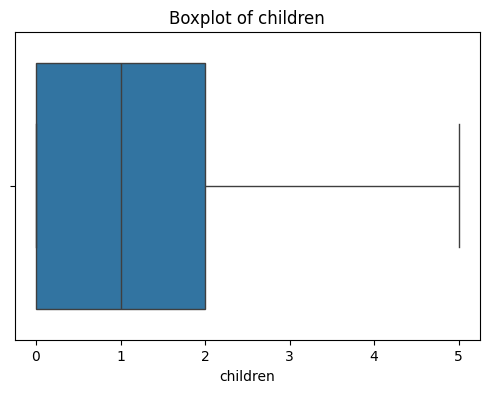

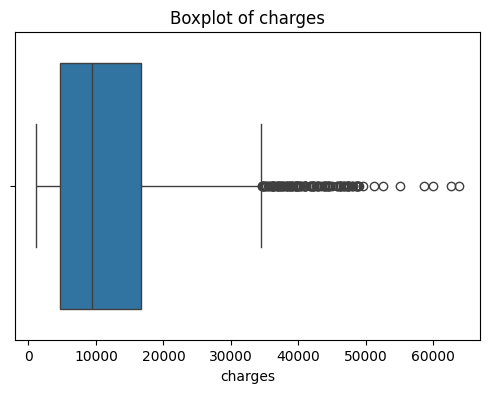

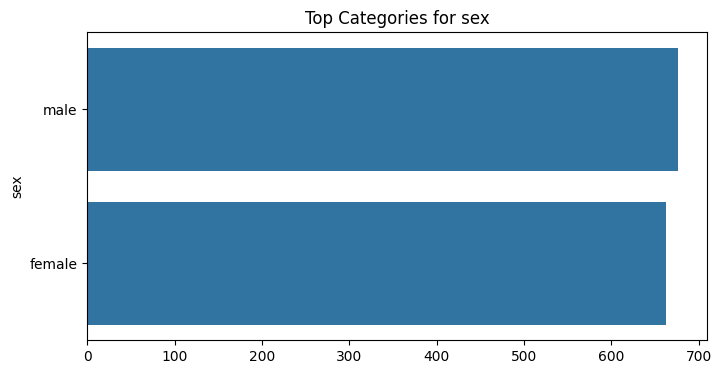

In [26]:
# Histogram for all numeric columns
numeric_df.hist(figsize=(15, 10))
plt.suptitle("Histograms of Numeric Columns")
plt.show()

# Boxplot for first few numeric columns
for c in numeric_df.columns[:5]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=numeric_df[c])
    plt.title(f"Boxplot of {c}")
    plt.show()

# Bar chart for top categories of first categorical column
if categorical_cols:
    col = categorical_cols[0]
    top_values = df[col].value_counts().head(10)
    plt.figure(figsize=(8,4))
    sns.barplot(x=top_values.values, y=top_values.index)
    plt.title(f"Top Categories for {col}")
    plt.show()

In [27]:
datetime_cols = [c for c, t in col_types.items() if t == "datetime"]
if datetime_cols and not numeric_df.empty:
    dt_col = datetime_cols[0]
    num_col = numeric_df.columns[0]
    temp_df = df[[dt_col, num_col]].dropna()
    temp_df[dt_col] = pd.to_datetime(temp_df[dt_col], errors='coerce')
    temp_df = temp_df.dropna()
    temp_df = temp_df.set_index(dt_col).resample("M").mean()
    temp_df[num_col].plot(figsize=(10,4), title=f"{num_col} over time (monthly)")
    plt.ylabel(num_col)
    plt.show()
else:
    print("No datetime columns detected for time series plot.")

No datetime columns detected for time series plot.


In [28]:
print("✅ EDA complete.")
print("Next steps: Use generate_insights.py to get plain-English insights, or app_streamlit.py to run dashboard.")

✅ EDA complete.
Next steps: Use generate_insights.py to get plain-English insights, or app_streamlit.py to run dashboard.


In [29]:
import os
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas

# Function to save report in PDF
def save_report_pdf(report_text, filename="report.pdf", folder="report"):
    os.makedirs(folder, exist_ok=True)
    filepath = os.path.join(folder, filename)

    c = canvas.Canvas(filepath, pagesize=A4)
    width, height = A4

    y = height - 50
    for line in report_text.split("\n"):
        c.drawString(50, y, line)
        y -= 20
        if y < 50:  # new page if space ends
            c.showPage()
            y = height - 50

    c.save()
    print(f"✅ Report saved at {filepath}")

# Example usage
report_text = """
Data Analysis Report

1. Dataset Summary
- Rows: 100
- Columns: 5

2. Key Insights
- Column A has missing values.
- Column B shows correlation with target.

3. Visualization Results
See generated plots.
"""

save_report_pdf(report_text, filename="analysis_report.pdf")


✅ Report saved at report\analysis_report.pdf
